<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Import Needed Libraries</h2>
</div>

In [94]:
import emoji
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from datasets import Dataset
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support , classification_report , confusion_matrix
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification , TrainingArguments , Trainer , EarlyStoppingCallback

<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Load Data</h2>
</div>

#### Load the Data and Concate into one Data

In [32]:
reddit_df = pd.read_csv('/kaggle/input/datasets/infamouscoder/depression-reddit-cleaned/depression_dataset_reddit_cleaned.csv')
twitter_train_df = pd.read_csv('/kaggle/input/datasets/samrats/depressiontweets/train2Data.csv')
twitter_test_df = pd.read_csv('/kaggle/input/datasets/samrats/depressiontweets/test2Data.csv')

#### Information about the datasets

In [33]:
print("Data1 (Reddit Dataset) Info:\n")
print(reddit_df.info())
print("Is there any missing data in Data1? ", reddit_df.isnull().sum().any(),"\n")
print("Is there any duplicate data in Data1? ", reddit_df.duplicated().sum(),"\n")
print("Is there any imbalance in the target variable in Data1? ", reddit_df['is_depression'].value_counts(),"\n")

Data1 (Reddit Dataset) Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7731 entries, 0 to 7730
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_text     7731 non-null   object
 1   is_depression  7731 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 120.9+ KB
None
Is there any missing data in Data1?  False 

Is there any duplicate data in Data1?  81 

Is there any imbalance in the target variable in Data1?  is_depression
0    3900
1    3831
Name: count, dtype: int64 



In [34]:
print("Data2 (DepressionTweets Train) Info:\n")
print(twitter_train_df.info())
print("Is there any missing data in Data2? ", twitter_train_df.isnull().sum().any(),"\n")
print("Is there any duplicate data in Data2? ", twitter_train_df.duplicated().sum(),"\n")
twitter_train_df.columns = twitter_train_df.columns.str.strip() # Remove leading/trailing whitespace from column names
print("Is there any imbalance in the target variable in Data2? ", twitter_train_df['Label'].value_counts(),"\n")

Data2 (DepressionTweets Train) Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31000 entries, 0 to 30999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Tweets  31000 non-null  object
 1    Label  31000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 484.5+ KB
None
Is there any missing data in Data2?  False 

Is there any duplicate data in Data2?  932 

Is there any imbalance in the target variable in Data2?  Label
1    16000
0    15000
Name: count, dtype: int64 



In [35]:
print("Data3 (DepressionTweets Test) Info:\n")
print(twitter_test_df.info())
print("Is there any missing data in Data3? ", twitter_test_df.isnull().sum().any(),"\n")
print("Is there any duplicate data in Data3? ", twitter_test_df.duplicated().sum(),"\n")
twitter_test_df.columns = twitter_test_df.columns.str.strip() # Remove leading/trailing whitespace from column names
print("Is there any imbalance in the target variable in Data3? ", twitter_test_df['Label'].value_counts(),"\n")

Data3 (DepressionTweets Test) Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31000 entries, 0 to 30999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Tweets  31000 non-null  object
 1    Label  31000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 484.5+ KB
None
Is there any missing data in Data3?  False 

Is there any duplicate data in Data3?  1956 

Is there any imbalance in the target variable in Data3?  Label
1    16000
0    15000
Name: count, dtype: int64 



#### Concatenate the datasets

In [36]:
reddit_df.rename(columns={"clean_text": "text", "is_depression": "label"}, inplace=True)
twitter_train_df.rename(columns={"Tweets": "text", "Label": "label"}, inplace=True)
twitter_test_df.rename(columns={"Tweets": "text", "Label": "label"}, inplace=True)

In [37]:
df = pd.concat([
    reddit_df[["text", "label"]], 
    twitter_train_df[["text", 'label']], 
    twitter_test_df[["text", 'label']], 
], ignore_index=True)

In [38]:
# Show the combined dataset info
print("Combined Dataset Info:\n")
print(df.info())
print("Is there any duplicate data in Combined Data?")
print(df.duplicated().sum())

Combined Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69731 entries, 0 to 69730
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    69731 non-null  object
 1   label   69731 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ MB
None
Is there any duplicate data in Combined Data?
2969


#### Handle Duplicates Rows (Remove It)

In [39]:
df.drop_duplicates(inplace=True)

In [40]:
# Show the combined dataset info after remove duplicates
print("Combined Dataset Info:\n")
print(df.info())
print("Is there any duplicate data in Combined Data?")
print(df.duplicated().sum())

Combined Dataset Info:

<class 'pandas.core.frame.DataFrame'>
Index: 66762 entries, 0 to 69730
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    66762 non-null  object
 1   label   66762 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.5+ MB
None
Is there any duplicate data in Combined Data?
0


<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Basic Dataset Overview (EDA)</h2>
</div>

#### Class Distribution (Check if dataset is balanced)

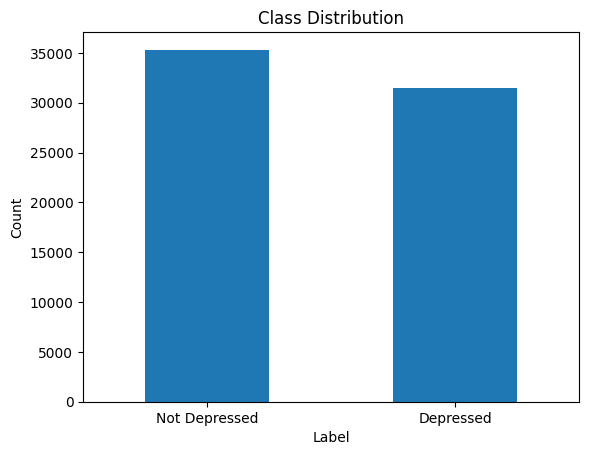

In [41]:
df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Label")
plt.xticks([0, 1], ["Not Depressed", "Depressed"],rotation=0)
plt.ylabel("Count")
plt.show()

*   **Dataset Balance:** The dataset is well-balanced, with approximately **35,000** samples labeled as "Not Depressed" and **32,000** samples labeled as "Depressed." 

*   **Modeling Significance:** This near-even distribution (approx. 52% to 48%) is ideal for binary classification. It ensures that the DistilBERT model will learn to identify patterns from both classes equally, preventing it from developing a bias toward a majority class.

*   **Metric Reliability:** Because the classes are balanced, **Accuracy** remains a reliable metric for this project. If the data were imbalanced, we would have to rely solely on F1-score or Area Under Curve (AUC).

#### Text Length Analysis

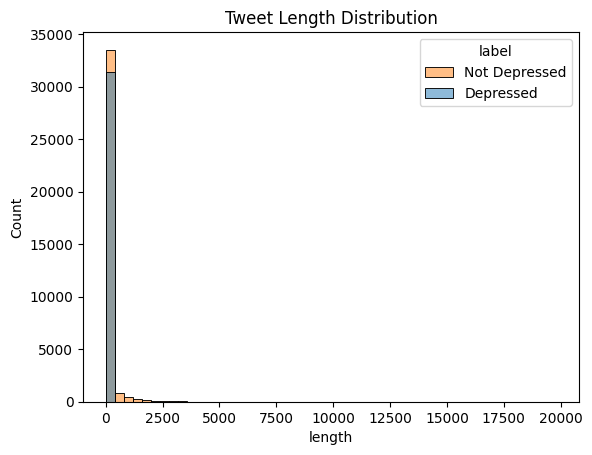

In [42]:
df['length'] = df['text'].apply(len)
df.groupby('label')['length'].describe()
sns.histplot(data=df, x='length', hue='label', bins=50)
plt.title("Tweet Length Distribution")
plt.legend(title='label', labels=['Not Depressed', 'Depressed'])
plt.show()

*   **Extreme Right Skewness:** Both classes are heavily right-skewed, meaning the vast majority of posts are relatively short (under 500 characters). This is typical for social media data (Twitter/Reddit).

*   **Narrative Outliers:** A significant observation is the "long tail" in the distribution. There are several posts in the **Depressed** class that exceed **10,000 to 20,000 characters**.

*   **Behavioral Pattern:** This suggests a distinct behavioral difference: while "Normal" sentiment is often concise, individuals in distress frequently use these platforms for **long-form venting or detailed personal narratives**. 

*   **Modeling Consideration:** Since DistilBERT has a maximum token limit (set to 128 in this project), these long-form posts will be truncated. However, the first 128 tokens are usually sufficient to capture the emotional "tone" and primary sentiment of the user.


#### Word Count Analysis

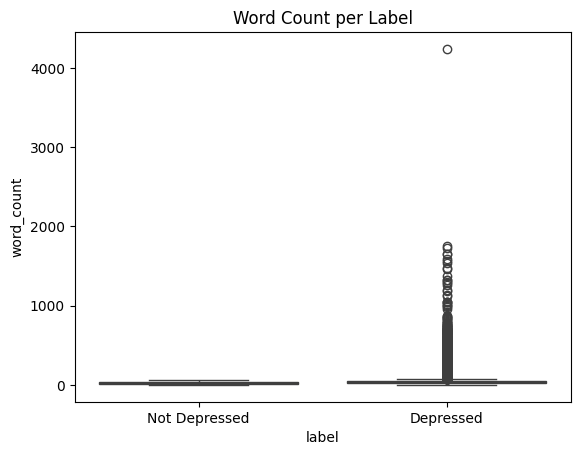

In [43]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

sns.boxplot(x='label', y='word_count', data=df)
plt.title("Word Count per Label")
plt.xticks([0, 1], ["Not Depressed", "Depressed"])
plt.show()

*   **Median Consistency:** The median word count for both "Not Depressed" and "Depressed" classes is relatively low and similar, suggesting that the average post across both categories is concise.

*   **Significant Outlier Variance:** There is a stark difference in the distribution of outliers. The **Depressed** class shows a massive cluster of outliers extending far beyond the upper quartile, with some posts exceeding **4,000 words**. In contrast, the "Not Depressed" class is much more compact.

*   **The "Venting" Phenomenon:** This pattern confirms a common psychological observation in NLP: individuals expressing depressive symptoms often use social media as a space for **"long-form venting"** or detailed personal storytelling to process their emotions.

#### Most Frequent Words

In [97]:
stop_words = set(stopwords.words('english'))

def clean_for_eda(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    words = [word for word in text.split() if word not in stop_words]
    
    return " ".join(words)

Depressed_text = " ".join(df[df.label == 1]['text'].apply(clean_for_eda))
no_Depressed_text = " ".join(df[df.label == 0]['text'].apply(clean_for_eda))

Depressed_words = Counter(Depressed_text.split()).most_common(20)
no_Depressed_words = Counter(no_Depressed_text.split()).most_common(20)

print("Depressed words:", Depressed_words)
print("No Depressed words:", no_Depressed_words)

Depressed words: [('depression', 14520), ('want', 12527), ('feel', 10994), ('like', 9906), ('cry', 9144), ('depressed', 8573), ('life', 8492), ('hate', 6422), ('get', 5984), ('stressed', 5798), ('anxiety', 5611), ('today', 5603), ('know', 5514), ('people', 5274), ('time', 4791), ('really', 4681), ('absolutely', 4493), ('damn', 4398), ('miserable', 4301), ('severe', 4297)]
No Depressed words: [('like', 4734), ('one', 2634), ('get', 2295), ('time', 2067), ('good', 1980), ('love', 1973), ('people', 1859), ('know', 1776), ('amp', 1744), ('favorite', 1683), ('best', 1627), ('would', 1580), ('voting', 1502), ('amas', 1469), ('think', 1431), ('really', 1397), ('day', 1379), ('see', 1378), ('dont', 1336), ('want', 1303)]


#### WordCloud Visualization

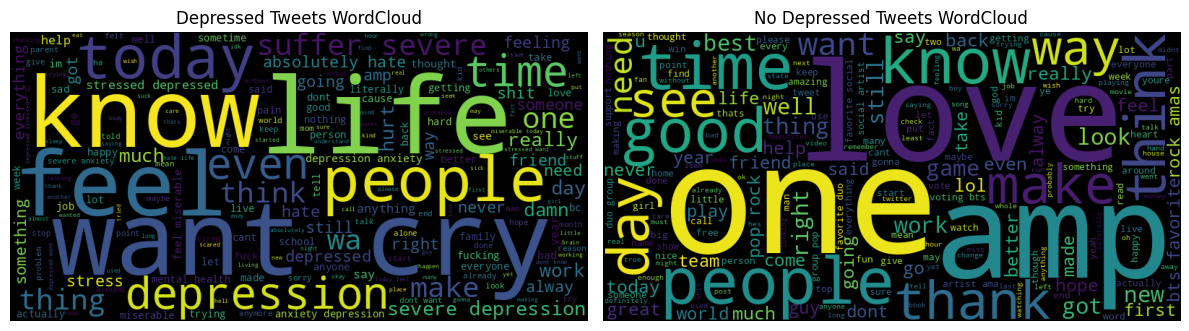

In [ ]:
plt.figure(figsize=(12, 6))  

plt.subplot(1, 2, 1)
wc_Depressed = WordCloud(width=800, height=400).generate(Depressed_text)
plt.imshow(wc_Depressed)
plt.axis("off")
plt.title("Depressed Tweets WordCloud")

plt.subplot(1, 2, 2)
wc_not_Depressed = WordCloud(width=800, height=400).generate(no_Depressed_text)
plt.imshow(wc_not_Depressed)
plt.axis("off")
plt.title("No Depressed Tweets WordCloud")

plt.tight_layout()
plt.show()  

*   **Depressed Class Patterns:** This cloud is characterized by high-intensity emotional tokens and introspective verbs. Frequent terms such as **"depression," "cry," "suffer," "severe,"** and **"miserable"** highlight a clear focus on mental distress. The prominence of words like **"want"** and **"feel"** suggests a heavy emphasis on internal states and unmet needs.

*   **Not Depressed Class Patterns:** In contrast, this cloud reflects positive social interactions and general daily life. The dominance of **"love," "good," "thank," "day,"** and **"best"** indicates a much more outward-looking and positive sentiment.

*   **Shared Vocabulary:** Words like **"time"** and **"people"** appear in both clouds, but their contextual usage likely differs—referring to "struggling all the time" in one class versus "having a good time" in the other.

#### Special Patterns (Count punctuation intensity)

In [46]:
df['exclamation'] = df['text'].apply(lambda x: x.count('!'))
df['question'] = df['text'].apply(lambda x: x.count('?'))

df.groupby('label')[['exclamation','question']].mean()

,exclamation,question
label,,
0,0.0,0.0
1,0.0,0.0


In [47]:
# Is Emojis a factor?
df['emoji_count'] = df['text'].apply(lambda x: sum(1 for c in x if c in emoji.EMOJI_DATA))
df.groupby('label')['emoji_count'].mean()

label
0    0.0
1    0.0
Name: emoji_count, dtype: float64

In [48]:
# URL / Mention / Hashtag Analysis is also a factor?
df['has_url'] = df['text'].str.contains("http").astype(int)
df['has_mention'] = df['text'].str.contains("@").astype(int)
df['has_hashtag'] = df['text'].str.contains("#").astype(int)

df.groupby('label')[['has_url','has_mention','has_hashtag']].mean()

,has_url,has_mention,has_hashtag
label,,,
0,0.004008,0.0,0.0
1,0.005634,0.0,0.0


<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Cleaning the Text</h2>
</div>

In [49]:
# Text Cleaning for Modeling
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)   # remove URLs
    text = re.sub(r"<.*?>", "", text)     # remove HTML
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [50]:
# Train-test split for modeling (70% train, 30% test and validation)
x_train, x_temp, y_train, y_temp = train_test_split(df['clean_text'],df['label'], test_size=0.3, random_state=42, stratify=df['label'])
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

#### Show the shapes of the splits

In [51]:
print(f"Number of Train Texts {x_train.shape}")
print(f"Number of Train Labels {y_train.shape}")
print(f"Number of Validation Texts {x_val.shape}")
print(f"Number of Validation Labels {y_val.shape}")
print(f"Number of Test Texts {x_test.shape}")  
print(f"Number of Test Labels {y_test.shape}")  

Number of Train Texts (46733,)
Number of Train Labels (46733,)
Number of Validation Texts (10014,)
Number of Validation Labels (10014,)
Number of Test Texts (10015,)
Number of Test Labels (10015,)


<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Modeling</h2>
</div>

#### Convert to HuggingFace Dataset

In [52]:
train_dataset = Dataset.from_dict({
    "clean_text": x_train.tolist(),
    "label": y_train.tolist()
})

val_dataset = Dataset.from_dict({
    "clean_text": x_val.tolist(),
    "label": y_val.tolist()
})

test_dataset = Dataset.from_dict({
    "clean_text": x_test.tolist(),
    "label": y_test.tolist()
})

#### Tokenization

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(example):
    return tokenizer(
        example["clean_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/46733 [00:00<?, ? examples/s]

Map:   0%|          | 0/10014 [00:00<?, ? examples/s]

Map:   0%|          | 0/10015 [00:00<?, ? examples/s]

#### Format for PyTorch

In [54]:
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

#### Load Model

In [55]:
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased",num_labels=2)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


#### Metrics

In [56]:
def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

#### Training Arguments

In [57]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [59]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [60]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.085210,0.052937,0.994008,0.994326,0.996399,0.992261
2,0.042200,0.059605,0.993809,0.994144,0.994896,0.993394
3,0.017265,0.057866,0.994108,0.994433,0.994152,0.994715
4,0.003544,0.068321,0.995007,0.995279,0.995843,0.994715
5,0.000962,0.079427,0.994807,0.995091,0.995467,0.994715


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=7305, training_loss=0.06135014473045631, metrics={'train_runtime': 1801.2427, 'train_samples_per_second': 129.724, 'train_steps_per_second': 4.056, 'total_flos': 7738248676738560.0, 'train_loss': 0.06135014473045631, 'epoch': 5.0})

#### Save The Model

In [62]:
model.save_pretrained("./stress_model")
tokenizer.save_pretrained("./stress_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./stress_model/tokenizer_config.json', './stress_model/tokenizer.json')

<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Evaluation on Test Data (Unseen)</h2>
</div>

#### Load Saved Model

In [102]:
tokenizer = AutoTokenizer.from_pretrained("./stress_model")
model = AutoModelForSequenceClassification.from_pretrained("./stress_model")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [103]:
def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v for k, v in inputs.items() if k != "token_type_ids"}

    with torch.no_grad():
        outputs = model(**inputs)

    return outputs.logits.argmax(dim=1).item()

In [104]:
test_results = trainer.evaluate(test_dataset)
print(test_results)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.08335722237825394, 'eval_accuracy': 0.9939091362955567, 'eval_f1': 0.994238216680835, 'eval_precision': 0.9952723146747352, 'eval_recall': 0.9932062653330818, 'eval_runtime': 24.0387, 'eval_samples_per_second': 416.62, 'eval_steps_per_second': 13.021, 'epoch': 5.0}


In [105]:
predictions = trainer.predict(test_dataset)
logits = predictions.predictions
labels = predictions.label_ids
y_pred = logits.argmax(axis=1)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [106]:
print(classification_report(labels, y_pred, target_names=["Not Depressed", "Depressed"]))

               precision    recall  f1-score   support

Not Depressed       0.99      0.99      0.99      4716
    Depressed       1.00      0.99      0.99      5299

     accuracy                           0.99     10015
    macro avg       0.99      0.99      0.99     10015
 weighted avg       0.99      0.99      0.99     10015



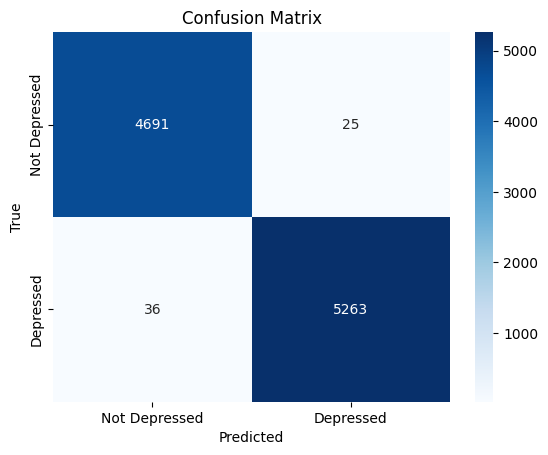

In [107]:
cm = confusion_matrix(labels, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Depressed", "Depressed"],
            yticklabels=["Not Depressed", "Depressed"])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Predicting and Evaluate on New Dataset</h2>
</div>



In [98]:
df_new = pd.read_csv("/kaggle/input/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/Combined Data.csv")
df_new.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [99]:
df_new = df_new[df_new['status'].isin(["Normal", "Depression"])]
df_new = df_new[['statement', 'status']]

In [100]:
label_map = {"Normal": 0,"Depression": 1}
df_new["label"] = df_new["status"].map(label_map)

In [101]:
df_new.head()

,statement,status,label
733,"Gr gr dreaming of ex crush to be my game, God",Normal,0
734,wkwkwk what a joke,Normal,0
735,Leaves are also standby in front of the PC ......,Normal,0
736,Thank God even though it's just a ride through,Normal,0
737,wedding teaser concept using the song day6 - o...,Normal,0


In [78]:
df_new["text"] = df_new["statement"].apply(clean_text)

In [82]:
df_new["pred"] = df_new["text"].apply(predict)

In [83]:
print("Accuracy:", accuracy_score(df_new["label"], df_new["pred"]))
print(classification_report(df_new["label"], df_new["pred"]))

Accuracy: 0.9216186427334279
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     16351
           1       0.88      0.97      0.92     15404

    accuracy                           0.92     31755
   macro avg       0.92      0.92      0.92     31755
weighted avg       0.93      0.92      0.92     31755



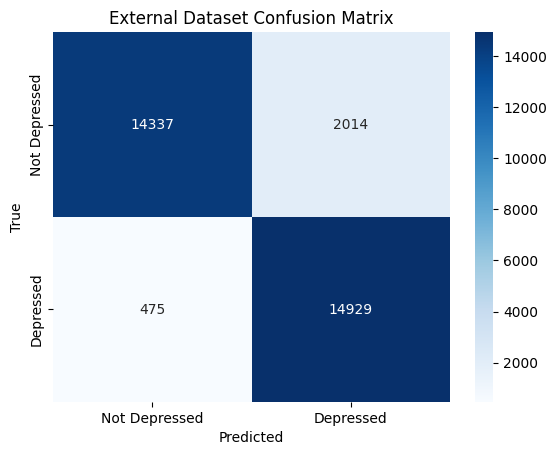

In [93]:
cm = confusion_matrix(df_new["label"], df_new["pred"])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Depressed", "Depressed"],
            yticklabels=["Not Depressed", "Depressed"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("External Dataset Confusion Matrix")
plt.show()

<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Thanks</h2>
</div>

